In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ppi_lm.data_scripts.gold_standard_dataset import GoldStandardDataset

In [2]:
data = GoldStandardDataset(data_dir="../data/gold_standard_data")

In [3]:
print(len(data.seqs))

20386


In [4]:
for split, pairs in data.pairs.items():
    n_pos = sum(label for _, _, label in pairs)
    n_neg = len(pairs) - n_pos
    print(
        f"{split:5s} | total {len(pairs):7d} | pos {n_pos:7d} | neg {n_neg:7d} "
        f"| {n_pos / len(pairs):.1%} pos"
    )

train | total  163192 | pos   81596 | neg   81596 | 50.0% pos
val   | total   59260 | pos   29630 | neg   29630 | 50.0% pos
test  | total   52048 | pos   26024 | neg   26024 | 50.0% pos


nombre     : 20386
moyenne    : 558
médiane    : 415
min / max  : 2 / 34350
25e centile : 250
75e centile : 670
90e centile : 1076
95e centile : 1454
99e centile : 2723


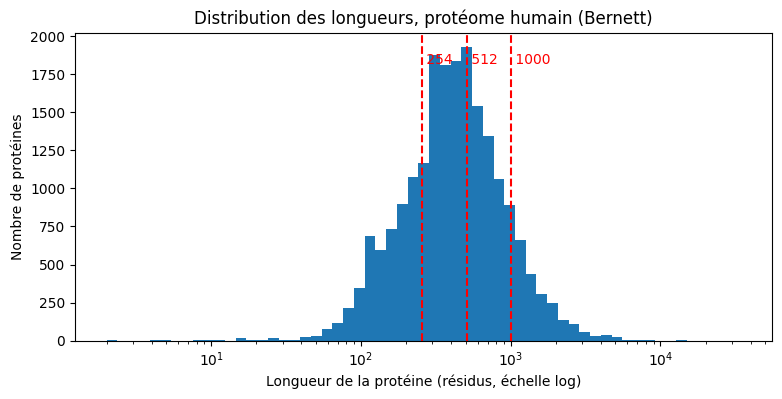

In [5]:
lengths = np.array([len(s) for s in data.seqs.values()])

print(f"nombre     : {len(lengths)}")
print(f"moyenne    : {lengths.mean():.0f}")
print(f"médiane    : {np.median(lengths):.0f}")
print(f"min / max  : {lengths.min()} / {lengths.max()}")
for p in [25, 75, 90, 95, 99]:
    print(f"{p}e centile : {np.percentile(lengths, p):.0f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 60))
ax.set_xscale("log")
for seuil in [254, 512, 1000]:
    ax.axvline(seuil, linestyle="--", color="red")
    ax.text(seuil, ax.get_ylim()[1] * 0.9, f" {seuil}", color="red")
ax.set_xlabel("Longueur de la protéine (résidus, échelle log)")
ax.set_ylabel("Nombre de protéines")
ax.set_title("Distribution des longueurs, protéome humain (Bernett)")
plt.show()

In [6]:
from pathlib import Path

ROOT = Path.cwd().parent

data = GoldStandardDataset(ROOT / "data" / "gold_standard_data", batch_size=8, num_workers=0)
batch = next(iter(data.mlm_loader("train")))
print({k: v.shape for k, v in batch.items()})

batch = next(iter(data.classif_loader("train")))
print({k: v.shape for k, v in batch.items()}, batch["labels"])

print(len(data.mlm_loader("train").dataset))  # 81596 paires positives
print(len(data.classif_loader("train").dataset))  # 163192 paires

{'input_ids': torch.Size([8, 1027]), 'segment_ids': torch.Size([8, 1027]), 'attention_mask': torch.Size([8, 1027]), 'labels': torch.Size([8, 1027])}
{'input_ids': torch.Size([8, 1027]), 'segment_ids': torch.Size([8, 1027]), 'attention_mask': torch.Size([8, 1027]), 'labels': torch.Size([8])} tensor([0., 1., 0., 0., 1., 0., 1., 1.])
81596
163192
